In [1]:
 import pandas as pd
from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import linkage
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import datasets

%matplotlib inline

In [2]:
data=np.array([[8,8],[2,9],[4,7],[6,8],[5,3],[4,4],[3,3],[0,1],[2,6],[6,5]]).astype(np.float64)
ys = np.array([0, 0, 0, 0,1,1,1,1,1,0])
#ctys = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']
ctys= range(ys.size)

In [3]:
#Secondo intermedio
#data=np.array([[1,1],[1,4],[1,9],[3,2],[3,5],[4,-1],[5,13],[6,6],[6,9],[8,3],[9,7],[10,-3]]).astype(np.float64)
#ys = np.array([0, 0, 0, 0,0,0,1,1,1,1,1,1])
#ctys = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']
#ctys= range(ys.size)

In [4]:
data1=np.concatenate((data,np.array([ys]).T), axis=1)

In [5]:
df = pd.DataFrame(data1, columns=['xcord', 'ycord','label'], index=ctys)
df.T

,0,1,2,3,4,5,6,7,8,9
xcord,8.0,2.0,4.0,6.0,5.0,4.0,3.0,0.0,2.0,6.0
ycord,8.0,9.0,7.0,8.0,3.0,4.0,3.0,1.0,6.0,5.0
label,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0


In [6]:
df.xcord.max()

8.0

In [7]:
xmin=df.xcord.min() -1
xmax=df.xcord.max()+1
ymin=df.ycord.min() -1
ymax=df.ycord.max()+1

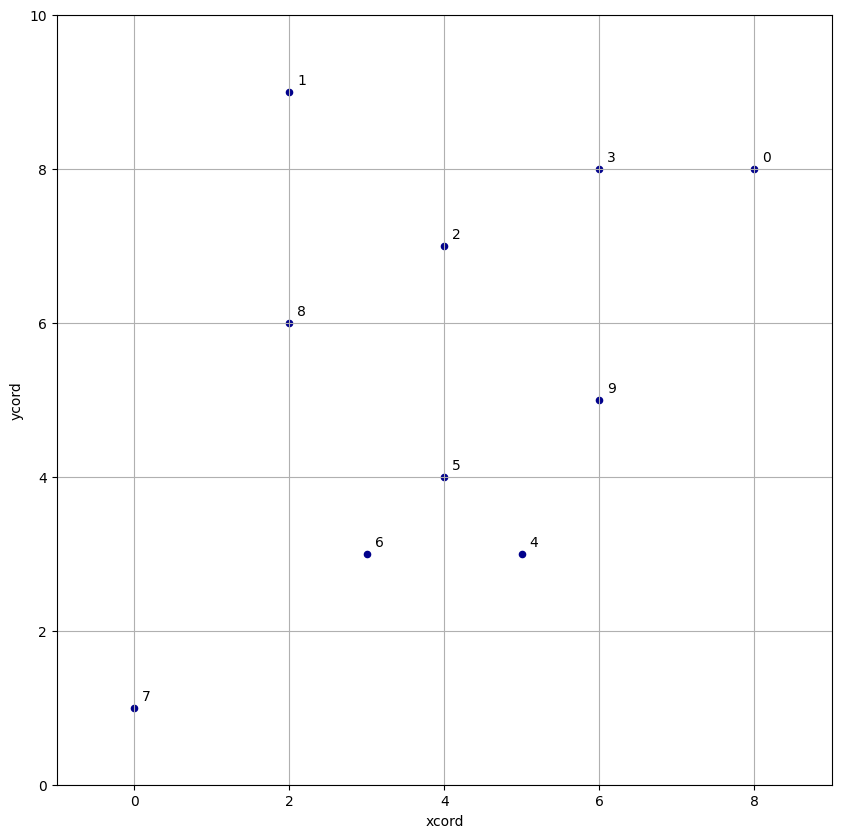

In [8]:
ax = df.plot.scatter(x='xcord',
                      y='ycord',
                      c='DarkBlue',grid=True,figsize=(10,10),xlim=(xmin,xmax),ylim=(ymin,ymax))
for i, point in df.iterrows():
        ax.text(point['xcord']+.1, point['ycord']+.1, str(i))


In [9]:

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin_scaled = 1/w[1]
    gutter_up = decision_boundary + margin_scaled
    gutter_down = decision_boundary - margin_scaled

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

    margin= 1 / np.sqrt(np.sum(svm_clf.coef_ ** 2))
    print("w0: "+str(w[0])+ "; w1: "+str(w[1])+"; b: "+str(b))
    print("Margin: "+str(margin))
    print("Support Vectors: ")
    print(svs)


In [10]:
svm_clf = SVC(kernel="linear", C=10^9)
svm_clf.fit(data, ys)

SVC(C=3, kernel='linear')

w0: -0.666666666666667; w1: -0.6666666666666665; b: 6.333333333333334
Margin: 1.0606601717798212
Support Vectors: 
[[2. 9.]
 [6. 5.]
 [5. 3.]
 [4. 4.]]


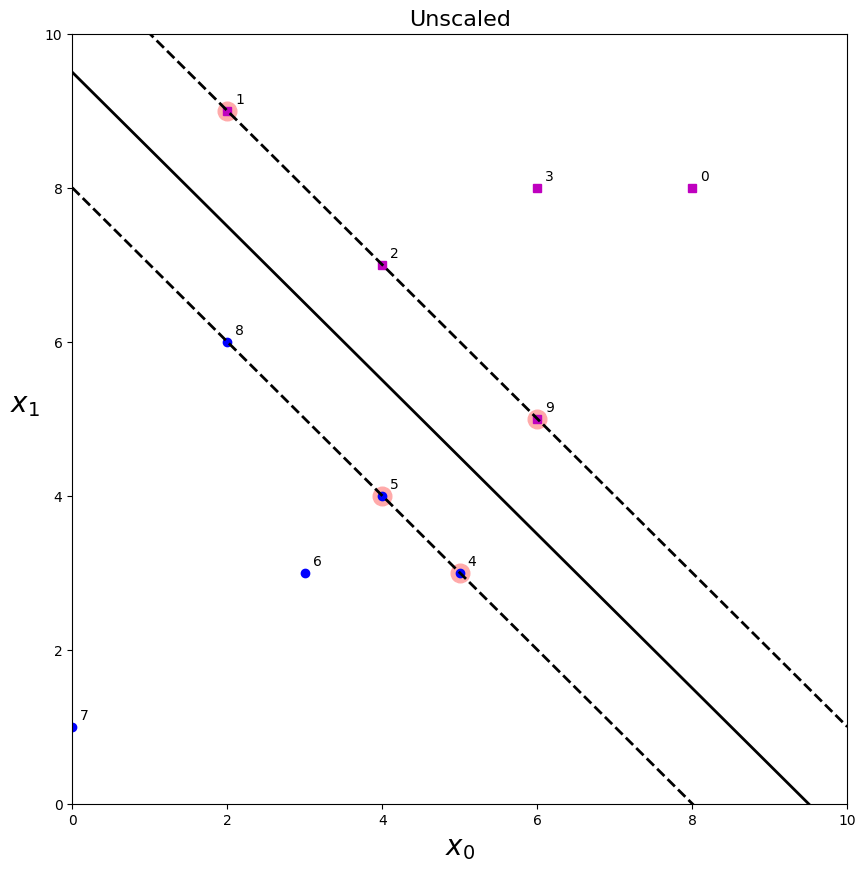

In [11]:
Xs=data
plt.figure(figsize=(10,10))
plt.subplot(111)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
maxX=max(df.xcord)+1
maxY=max(df.ycord)+1
all_max=max(maxX,maxY)
maxX=all_max
maxY=all_max
plot_svc_decision_boundary(svm_clf, 0, maxX)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1$    ", fontsize=20, rotation=0)
plt.title("Unscaled", fontsize=16)
plt.axis([0, maxX, 0, maxY])
for i, point in df.iterrows():
        plt.text(point['xcord']+.1, point['ycord']+.1, str(i))
